In [2]:
from matplotlib import pyplot as plt

from pylinac.core.image_generator import AS1200Image, AS1000Image
import pylinac.core.image_generator.layers as layers
from pylinac.core.image_generator.utils import generate_lightrad, generate_winstonlutz

import numpy as np

import pydicom

from scipy import ndimage


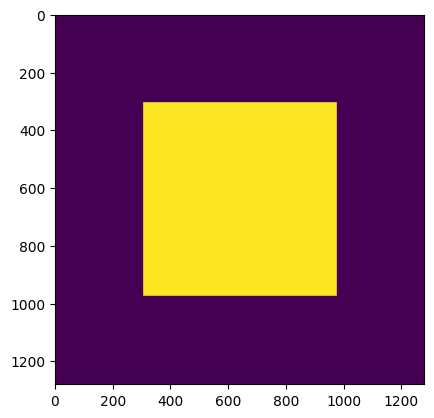

In [47]:
as1200perfect = AS1200Image()  # this will set the pixel size and shape automatically
as1200perfect.add_layer(layers.PerfectFieldLayer(field_size_mm=(150, 150)))  
as1200perfect.generate_dicom(file_out_name="perfect_AS1200.dcm", gantry_angle=45)  # create a DICOM file with the simulated image

plt.imshow(
    as1200perfect.image)

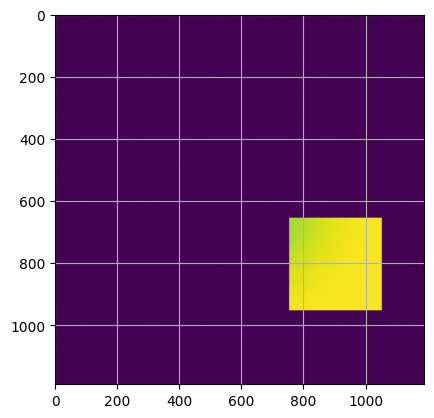

In [ ]:
as1200 = AS1200Image(sid=1000)  # this will set the pixel size and shape automatically

#as1200.shape = (1190, 1190)  
as1200.add_layer(layers.ConstantLayer(constant=0.4))
#as1200.add_layer(layers.FilterFreeFieldLayer(field_size_mm=(150, 150)))
#as1200.add_layer(layers.PerfectFieldLayer(field_size_mm=(150, 150), alpha=0.7))
# as1200.add_layer(layers.FilterFreeFieldLayer(
#     field_size_mm=(100, 100), 
#     alpha=1.0, 
#     gaussian_height=0.4, 
#     gaussian_sigma_mm=100.0,
#     cax_offset_mm=(55, 88))) 
as1200.add_layer(layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.2, 
    gaussian_sigma_mm=50.0,
    cax_offset_mm=(55, 88))
)
 
as1200.add_layer(layers.GaussianFilterLayer(sigma_mm=2))  # add an image-wide gaussian to simulate penumbra/scatter
as1200.add_layer(layers.RandomNoiseLayer(sigma=0.01)) 

as1200.generate_dicom(file_out_name="EPID_Jaw OA 10x10.dcm", gantry_angle=90)
plt.grid(True)
plt.imshow(as1200.image[0:1190, 0:1190])


In [6]:
generate_lightrad(
    file_out="lightrad.dcm",
    simulator=AS1200Image(sid=1000),
    field_layer=layers.FilterFreeFieldLayer
)

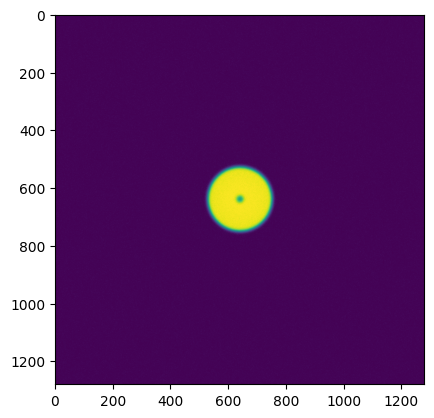

In [3]:
as1200 = AS1200Image()
as1200.add_layer(layers.FilterFreeConeLayer(50))
as1200.add_layer(layers.PerfectBBLayer(bb_size_mm=5))
as1200.add_layer(layers.GaussianFilterLayer(sigma_mm=2))
as1200.add_layer(layers.RandomNoiseLayer(sigma=0.02))
# plot the generated image
plt.imshow(as1200.image)

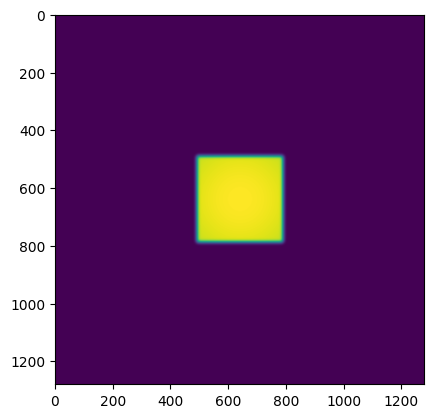

In [6]:
as1200 = AS1200Image(sid=1000)  # this will set the pixel size and shape automatically

#as1200.shape = (1190, 1190)  
as1200.add_layer(layers.ConstantLayer(constant=0.4))
#as1200.add_layer(layers.FilterFreeFieldLayer(field_size_mm=(150, 150)))
#as1200.add_layer(layers.PerfectFieldLayer(field_size_mm=(150, 150), alpha=0.7))
as1200.add_layer(layers.FilterFreeFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.4, 
    gaussian_sigma_mm=100.0,
    cax_offset_mm=(0, 0))) 
# as1200.add_layer(layers.FilteredFieldLayer(
#     field_size_mm=(100, 100), 
#     alpha=1.0, 
#     gaussian_height=0.2, 
#     gaussian_sigma_mm=50.0,
#     cax_offset_mm=(55, 88))
# )
 
as1200.add_layer(layers.GaussianFilterLayer(sigma_mm=2))  # add an image-wide gaussian to simulate penumbra/scatter

as1200.generate_dicom(file_out_name="EPID_Jaw 10x10.dcm", gantry_angle=90)
plt.imshow(as1200.image)
